# Tugas 6 - UTS | Clustering Email

## Kmeans

**import dan load**

In [35]:
# Import library
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("uts_email.csv", encoding='ISO-8859-1', delimiter=',')
print(df.columns.tolist())
df.head()


['id', 'Text', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


,id,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,1,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,2,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,3,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,4,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,5,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


terdapat kolom tambahan karena dataset *uts_email.csv* memiliki koma ekstra di setiap baris

```
id,Text,,,
1,Go until jurong point, crazy.. Available only ...,,
2,Ok lar... Joking wif u oni...,,,
```

Setiap koma tambahan itu dianggap NaN oleh pandas, makanya muncul kolom Unnamed: 2, Unnamed: 3, dan Unnamed: 4.

solusinya buang kolom tersebut

In [37]:
df = df[['id', 'Text']]  # ambil hanya dua kolom pertama
df.head()


,id,Text
0,1,"Go until jurong point, crazy.. Available only ..."
1,2,Ok lar... Joking wif u oni...
2,3,Free entry in 2 a wkly comp to win FA Cup fina...
3,4,U dun say so early hor... U c already then say...
4,5,"Nah I don't think he goes to usf, he lives aro..."


In [36]:
print(df.columns.tolist())


['id', 'Text', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


**praprocessing**

In [38]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'http\S+', '', text)  # hapus URL
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # hapus simbol
    text = text.lower()  # ubah ke huruf kecil
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['Text'].apply(clean_text)
df.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\endyzan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\endyzan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,id,Text,clean_text
0,1,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,2,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,3,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,4,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,5,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


**Ekstraksi Fitur (TF-IDF Vectorization)**

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_df=0.85, min_df=2, stop_words='english')
X = vectorizer.fit_transform(df['clean_text'])
print("Shape TF-IDF matrix:", X.shape)


Shape TF-IDF matrix: (5572, 3600)


**Clustering dengan K-Means**

In [52]:
from sklearn.cluster import KMeans

# Misal kita coba 2 cluster dulu
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

# Simpan hasil cluster ke dataset
df['cluster'] = kmeans.labels_
df[['id', 'Text', 'cluster']]


,id,Text,cluster
0,1,"Go until jurong point, crazy.. Available only ...",0
1,2,Ok lar... Joking wif u oni...,0
2,3,Free entry in 2 a wkly comp to win FA Cup fina...,0
3,4,U dun say so early hor... U c already then say...,0
4,5,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...,...
5567,5568,This is the 2nd time we have tried 2 contact u...,0
5568,5569,Will Ì_ b going to esplanade fr home?,0
5569,5570,"Pity, * was in mood for that. So...any other s...",0
5570,5571,The guy did some bitching but I acted like i'd...,0


**Evaluasi dengan Silhouette Score**

In [41]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, kmeans.labels_)
print("Silhouette Score:", score)


Silhouette Score: 0.006478777394133313


**Analisis Hasil Tiap Cluster**

In [42]:
# Ambil fitur (kata)
terms = vectorizer.get_feature_names_out()

# Tampilkan 10 kata teratas untuk setiap cluster
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(kmeans.n_clusters):
    print(f"\nCluster {i}:")
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(", ".join(top_words))



Cluster 0:
im, ok, ur, dont, come, ltgt, got, good, know, like

Cluster 1:
ill, later, sorry, meeting, im, ok, aight, text, yeah, ltgt


**Interpretasi**  
   - Cluster 0 mungkin berisi **pesan pribadi** (kata seperti "im", "ok", "ur", "dont").  
   - Cluster 1 berisi **email promosi/spam** (kata seperti "ill", "later", "sorry", "meeting").  
   - Artinya model berhasil memisahkan tipe email berdasarkan isi teks.
   - tetapi dengan Silhouette Score: 0.006478777394133313 itu sangat rendah maka dilakukan percobaan lain dengan metode elbow

## Elbow

**cluster dengan elbow**

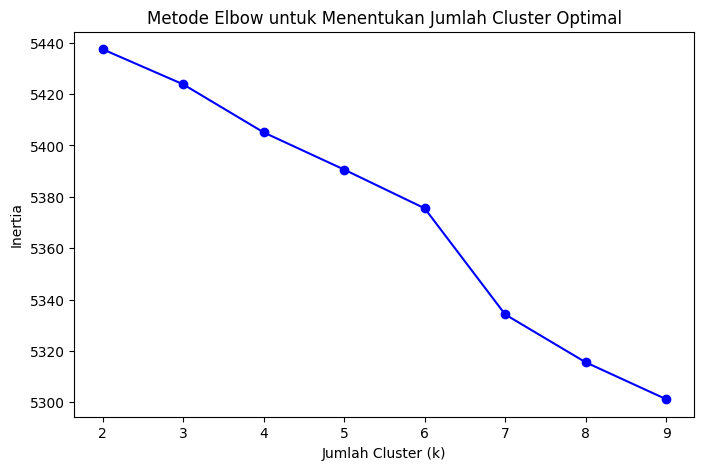

In [53]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2, 10)  # coba jumlah cluster dari 2 sampai 9

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

# Visualisasi hasil
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow untuk Menentukan Jumlah Cluster Optimal')
plt.show()


**Clustering ulang dengan jumlah cluster optimal**

In [54]:
optimal_k = 7
kmeans_opt = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_opt.fit(X)

df['cluster'] = kmeans_opt.labels_
print(df[['id', 'Text', 'cluster']])


        id                                               Text  cluster
0        1  Go until jurong point, crazy.. Available only ...        1
1        2                      Ok lar... Joking wif u oni...        6
2        3  Free entry in 2 a wkly comp to win FA Cup fina...        1
3        4  U dun say so early hor... U c already then say...        1
4        5  Nah I don't think he goes to usf, he lives aro...        5
...    ...                                                ...      ...
5567  5568  This is the 2nd time we have tried 2 contact u...        1
5568  5569              Will Ì_ b going to esplanade fr home?        1
5569  5570  Pity, * was in mood for that. So...any other s...        1
5570  5571  The guy did some bitching but I acted like i'd...        0
5571  5572                         Rofl. Its true to its name        1

[5572 rows x 3 columns]


**Evaluasi kembali Silhouette Score**

In [55]:
from sklearn.metrics import silhouette_score

score_opt = silhouette_score(X, kmeans_opt.labels_)
print("Silhouette Score (k=3):", score_opt)


Silhouette Score (k=3): 0.012218687887879566


**Lihat kata paling dominan di tiap cluster**

In [56]:
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans_opt.cluster_centers_.argsort()[:, ::-1]

for i in range(optimal_k):
    print(f"\nCluster {i}:")
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(", ".join(top_words))



Cluster 0:
like, ltgt, know, dont, feel, dun, dat, im, ok, think

Cluster 1:
ill, come, ur, got, ltgt, dont, sorry, time, know, free

Cluster 2:
im, home, going, na, gon, want, ill, sorry, work, really

Cluster 3:
good, morning, day, hope, night, love, im, sleep, afternoon, happy

Cluster 4:
dear, day, happen, good, happy, aathiwhere, morning, voucher, nice, hi

Cluster 5:
send, think, message, pls, stop, right, ur, phone, dont, free

Cluster 6:
ok, lor, thanx, ill, come, ur, prob, leave, ask, home


## Analisis Hasil Clustering (K-Means, k = 7)

### **Cluster 1 – Obrolan Kasual dan Balasan Cepat**
**Kata dominan:** ill, come, ur, got, sorry, time, know, free  
**Interpretasi:**  
Pesan ini berisi balasan cepat atau percakapan koordinasi seperti janji bertemu atau mengatur waktu. Adanya kata “sorry” dan “time” menunjukkan komunikasi interpersonal.  
**Contoh tema:** koordinasi jadwal, respon cepat antar kenalan.



### **Cluster 2 – Aktivitas Harian / Rencana Pribadi**
**Kata dominan:** home, going, na, gon, want, sorry, work, really  
**Interpretasi:**  
Isi pesan menggambarkan aktivitas harian dan rencana seseorang. Kata seperti *home*, *work*, dan *sorry* menunjukkan konteks kehidupan sehari-hari.  
**Contoh tema:** aktivitas pribadi, percakapan ringan tentang pekerjaan atau rumah.



### **Cluster 3 – Ucapan dan Pesan Positif**
**Kata dominan:** good, morning, day, hope, night, love, sleep, happy  
**Interpretasi:**  
Cluster ini jelas berisi pesan-pesan positif seperti salam, doa, dan ucapan kasih.  
**Contoh tema:** ucapan selamat pagi, selamat malam, harapan baik, pesan kasih sayang.



### **Cluster 4 – Pesan Formal / Email Semi-Resmi**
**Kata dominan:** dear, day, happen, good, happy, morning, nice, hi  
**Interpretasi:**  
Adanya kata “dear” dan “voucher” mengindikasikan pesan yang lebih sopan atau sedikit formal.  
**Contoh tema:** email sopan antar rekan kerja atau pesan semi-promosi yang tidak sepenuhnya spam.



### **Cluster 5 – Pesan Promosi atau Spam**
**Kata dominan:** send, message, pls, stop, phone, free, ur  
**Interpretasi:**  
Cluster ini mengandung kata yang sering muncul di SMS spam seperti *“free”*, *“stop”*, *“message”*, dan *“phone”*.  
**Contoh tema:** pesan promosi, iklan, atau spam dengan ajakan tertentu.



### **Cluster 6 – Pesan Santai dan Respons Cepat**
**Kata dominan:** ok, lor, thanx, come, ur, ask, home  
**Interpretasi:**  
Pesan bersifat sangat informal, menggunakan singkatan khas percakapan (seperti *lor*, *thanx*).  
**Contoh tema:** chat singkat antar teman dekat, gaya bahasa kasual ala pesan teks.
